# Geração v2 — recombinação Zhang–Shasha, passo a passo

**Ideia em uma frase:** pegar um anel (com 1 substituinte), achar outro anel *bem diferente* dele
(distância de árvore), uni-los por uma ponte e só aceitar a molécula se ela for química e
estruturalmente válida e nova — aprendendo com cada acerto e erro.

**Roteiro**

| # | Etapa | Pergunta que responde |
|---|---|---|
| 0 | Diagnóstico | Por que tantas junções falhavam? |
| 1 | Catálogo e árvores | O que é uma "árvore de anel" e por que todas têm o mesmo formato? |
| 2 | Distância (TED) | Como medir se dois anéis são diferentes? |
| 3 | Junção por valência | Como ligar dois anéis sem estourar valência? |
| 4 | Aromatização C/N | Quando um anel pode virar aromático? |
| 5 | Rebote, passo a passo | O que acontece quando a primeira escolha é rejeitada? |
| 6 | Geração 1 e loop | Como isso roda em escala, geração após geração? |
| 7 | Aprendizado | O que o sistema aprendeu a cada ciclo? |
| 8 | Guia por interesse | Como empurrar a geração para o que importa? |
| 9 | Resultados | Quantas moléculas, com que qualidade? |

In [1]:
import sys, random
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
RDLogger.DisableLog("rdApp.*")

RAIZ = Path.cwd()
if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))
import geracao.recombinacao_v2 as v2
from geracao.recombinacao_v2 import (
    catalogo_aneis, validar_arvores_uniformes, geracao_inicial, rodar_uma_geracao_v2,
    Memoria, interesse_conjugacao, ted_normalizada, ligar, sanitizar_tolerante,
    aromatizar_aneis_6,
)

# ---- parâmetros (mexa aqui) --------------------------------------------------
CAMINHO_BASE = RAIZ / "base_daniel.csv"
N_SUBSTITUINTES = 1          # a árvore tem sempre ANEL -> N x (POS -> FRAG)
N_SONDAS = 10                # 1ª rejeitada -> rebote em até 9 outras sondas
N_GERACOES = 5               # inclui a Geração 1
PESO_INTERESSE = 0.0         # 0 = só distância TED; >0 = distância + peso*interesse
SEMENTE_BASE = 44
INTERESSE = interesse_conjugacao   # f(mol) -> [0,1]; troque pelo critério real

## 0. Diagnóstico — por que tantas junções falhavam?

**O que faz:** reproduz o método antigo (colar `anel1 + ponte + anel2` como texto) em 20.000 pares
sorteados e conta quem quebra, por ponte.

**Por quê:** só dá para consertar o que se entende. Antes de mudar código, medimos a causa.

**O que observar:** as pontes terminadas em `=` concentram *todas* as falhas.

In [2]:
df_base = pd.read_csv(CAMINHO_BASE, index_col=0)
pontes = df_base[["ID_Ponte", "Ponte_Estrutura"]].drop_duplicates().to_dict("records")
aneis_3 = df_base["SMILES_Modificado_Anel1"].tolist()
aneis_3b = df_base["SMILES_Modificado_Anel2"].tolist()

rng = random.Random(1)
tent, falha = Counter(), Counter()
for _ in range(20000):
    p = rng.choice(pontes)["Ponte_Estrutura"]
    smi = rng.choice(aneis_3) + p + rng.choice(aneis_3b).replace("1", "2")
    m = Chem.MolFromSmiles(smi)          # método antigo: colar texto
    tent[p] += 1
    falha[p] += m is None
tab = pd.DataFrame({"tentativas": tent, "falhas": falha})
tab["taxa_falha"] = (tab["falhas"] / tab["tentativas"]).round(3)
tab["termina_em_igual"] = [p.endswith("=") or p.startswith("=") for p in tab.index]
print(f"Falha global do método antigo: {tab['falhas'].sum() / tab['tentativas'].sum():.1%}")
tab.sort_values("taxa_falha", ascending=False)

Falha global do método antigo: 10.1%


,tentativas,falhas,taxa_falha,termina_em_igual
=,1014,605,0.597,True
=CC=,958,559,0.584,True
C=,1026,429,0.418,True
N=,1012,417,0.412,True
C=CC(=O),1011,0,0.000,False
C=C(C)C=C,1001,0,0.000,False
C=CC=C,1056,0,0.000,False
C=CC=CC,957,0,0.000,False
C=CC=CC=CC=C,1004,0,0.000,False
NC,1018,0,0.000,False


## 1. Catálogo de anéis e árvores uniformes

**O que faz:** extrai da base cada anel único (anel-base + posição + fragmento) e monta uma árvore:

```
ANEL:C1CCCCC1
└── POS:2
    └── FRAG:N
```

**Por quê:** a distância de Zhang–Shasha compara árvores. Se algumas tivessem 3 substituintes e
outras 1, a distância mediria *tamanho*, não *diferença química*. Com forma fixa (`ANEL → k×(POS→FRAG)`,
preenchendo com `-` o que faltar) a distância mede só rótulos.

**O que observar:** `Todas as árvores com os mesmos constituintes: True`.

In [3]:
aneis, avisos = catalogo_aneis(df_base, k=N_SUBSTITUINTES)
print(f"Anéis no catálogo: {len(aneis):,}  |  avisos: {dict(avisos)}")
print(f"Todas as árvores com os mesmos constituintes: {validar_arvores_uniformes(aneis)}")
print(f"Pontes: {len(pontes)}")

a = aneis[0]
print("\nExemplo de anel:", a.smiles, "| subs:", a.subs)
def mostrar(no, nivel=0):
    print("  " * nivel + no.label)
    for f in no.children:
        mostrar(f, nivel + 1)
mostrar(a.arvore)

Anéis no catálogo: 2,152  |  avisos: {'anel_sem_kekule_mantido': 25}
Todas as árvores com os mesmos constituintes: True
Pontes: 20

Exemplo de anel: C1(N)CCCCC1 | subs: (('2', 'N'),)
ANEL:C1CCCCC1
  POS:2
    FRAG:N


## 2. Distância entre anéis (Zhang–Shasha / TED)

**O que faz:** conta quantas edições (trocar, inserir, remover nó) transformam uma árvore na outra,
dividido pelo tamanho. 0 = iguais, 1 = nada em comum.

**Por quê:** é o critério de *diversidade*: parear anéis muito diferentes gera moléculas menos redundantes.

**O que observar:** como a forma é fixa, há **empates** (muitos pares com a mesma distância).
O rebote (etapa 5) embaralha os empates para não favorecer sempre os primeiros índices.

In [4]:
rng = random.Random(0)
amostra = rng.sample(aneis, 6)
for x in amostra[1:]:
    print(f"{amostra[0].smiles:28s} vs {x.smiles:28s}  TED = {ted_normalizada(amostra[0].arvore, x.arvore):.2f}")

dists = [ted_normalizada(*(y.arvore for y in rng.sample(aneis, 2))) for _ in range(2000)]
print("\nDistribuição em 2.000 pares:", dict(sorted(Counter(round(d, 2) for d in dists).items())))

B1(S(=O)=O)CCCCC1            vs N1SC(N(CC)CC)CCC1             TED = 1.00
B1(S(=O)=O)CCCCC1            vs S1C(C(F)(F)F)CCCC1            TED = 1.00
B1(S(=O)=O)CCCCC1            vs S1(N)NCCC1                    TED = 0.67
B1(S(=O)=O)CCCCC1            vs c1cc(N(C)C)cc1                TED = 1.00
B1(S(=O)=O)CCCCC1            vs C1N(Cl)CCC1                   TED = 1.00



Distribuição em 2.000 pares: {np.float64(0.33): 56, np.float64(0.67): 776, np.float64(1.0): 1168}


## 3. Junção por valência (a correção principal)

**O que faz:** em vez de colar a ponte no *último/primeiro caractere* do SMILES, escolhe em cada anel
um átomo que tenha **hidrogênios livres suficientes** para a ordem da ligação que a ponta da ponte
exige (`=` precisa de 2 H; ligação simples, 1 H). Depois liga os átomos pela API do RDKit.

**Por quê:** a ponta `=` em um átomo já substituído ou sem H estoura a valência. Era a causa de 100% das falhas.

**O que observar:** o mesmo par que quebra no método antigo sai válido no novo.

Método antigo (colar texto): C1(C(=O)[O][Na])CNCCC1=O2C(Cl)CSCC2 -> INVÁLIDO
Método novo: átomos de encaixe (9, 6), status=ok -> O=C([O][Na])C1CNCCC1=C1CSCC(Cl)O1


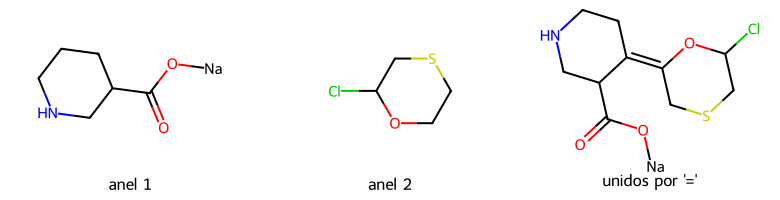

In [5]:
# Procura um par + ponte "=" que quebra no método antigo
rng = random.Random(3)
ponte_igual = next(p for p in pontes if p["Ponte_Estrutura"] == "=")
for _ in range(500):
    a, b = rng.sample(aneis, 2)
    antigo = a.smiles + "=" + b.smiles.replace("1", "2")
    if Chem.MolFromSmiles(antigo) is None:
        break
print("Método antigo (colar texto):", antigo, "->", "INVÁLIDO")

mol, enc = ligar(a.mol, "=", b.mol, random.Random(1))
mol, status = sanitizar_tolerante(mol)
print(f"Método novo: átomos de encaixe {enc}, status={status} ->", Chem.MolToSmiles(mol))
Draw.MolsToGridImage([a.mol, b.mol, mol], legends=["anel 1", "anel 2", "unidos por '='"], subImgSize=(260, 200))

In [6]:
# Antes x depois, em escala, nos MESMOS pares/pontes
rng = random.Random(11)
antigo_ok = novo_ok = kek = n = 0
for _ in range(5000):
    a, b = rng.sample(aneis, 2)
    p = rng.choice(pontes)["Ponte_Estrutura"]
    n += 1
    antigo_ok += Chem.MolFromSmiles(a.smiles + p + b.smiles.replace("1", "2")) is not None
    m, _ = ligar(a.mol, p, b.mol, rng)
    if m is not None:
        m, st = sanitizar_tolerante(m)
        novo_ok += m is not None
        kek += st == "sem_kekule"
print(f"Válidas — antigo: {antigo_ok / n:.1%}  |  novo: {novo_ok / n:.1%}  (das quais {kek} sem Kekulé, mantidas e sinalizadas)")

Válidas — antigo: 68.5%  |  novo: 99.8%  (das quais 90 sem Kekulé, mantidas e sinalizadas)


**Kekulé não é mais fatal.** Quando o RDKit não consegue atribuir ligações duplas alternadas
(ex.: anel `c1cccc1`, 5 carbonos aromáticos), a molécula é mantida com `kekule_ok=False`,
usando uma sanitização sem as etapas de Kekulé/aromaticidade. Erro de **valência** continua descartando,
porque aí a química está realmente errada.

## 4. Aromatização restrita a anéis C/N

**O que faz:** o projeto aromatiza anéis saturados de 6 membros. Agora só aromatiza anéis cujos 6 átomos
são **C ou N**. Anéis com O, S ou B ficam como estão. Depois confere se o RDKit **relê** o SMILES gerado
(ida-e-volta); se não relê, a molécula permanece na forma não aromatizada (`aromatizada=False`), sem ser descartada.

**Por quê:** aromatizar tudo gerava strings que o RDKit não relia em ~55% dos casos (anéis com S/O não
fecham a conta de elétrons π).

**O que observar:** o contraste entre um anel C/N e um anel com S.

In [7]:
exemplos = {"ciclohexano (C)": "C1CCCCC1", "piperidina (C/N)": "C1CCNCC1",
            "tiano (S)": "C1CCSCC1", "morfolina (O/N)": "N1CCOCC1"}
linhas = []
for nome, smi in exemplos.items():
    m = Chem.MolFromSmiles(smi)
    r = aromatizar_aneis_6(m)
    linhas.append({"anel": nome, "entrada": smi, "saída": Chem.MolToSmiles(r) if r else None,
                   "aromatizou": r is not None and Chem.MolToSmiles(r) != Chem.MolToSmiles(m)})
pd.DataFrame(linhas)

,anel,entrada,saída,aromatizou
0,ciclohexano (C),C1CCCCC1,C1:C:C:C:C:C:1,True
1,piperidina (C/N),C1CCNCC1,C1:C:C:N:C:C:1,True
2,tiano (S),C1CCSCC1,C1CCSCC1,False
3,morfolina (O/N),N1CCOCC1,C1COCCN1,False


## 5. O rebote, passo a passo (para uma semente)

**O que faz:** para um anel-semente, sorteia 10 anéis candidatos, ordena do **mais distante ao menos distante**
e tenta o primeiro. Se for rejeitado (junção, valência, duplicata, já existente), "rebate" para o próximo,
até 9 outras versões de distância igual ou levemente menor, e aceita a primeira aceitável.

Se as 10 sondas falham, a **escada de fallback** entra: (2) troca a ordem dos anéis → (3) testa todas as
pontes → (4) sorteia novos lotes de sondas. Assim a troca de anéis sempre existe.

**O que observar:** a tabela mostra cada sonda, sua distância e o veredito.

In [8]:
semente = random.Random(5).choice(aneis)
rng = random.Random(21)
mem_demo = Memoria()
idx = rng.sample(range(len(aneis)), N_SONDAS)
lote = [(i, ted_normalizada(semente.arvore, aneis[i].arvore)) for i in idx]
rng.shuffle(lote)                         # empates embaralhados
lote.sort(key=lambda p: p[1], reverse=True)

print("Semente:", semente.smiles)
linhas, vistos, est = [], set(), Counter()
for ordem, (i, dist) in enumerate(lote, 1):
    ponte = rng.choice(pontes)
    r = v2._tentar(semente, aneis[i], ponte, rng, mem_demo, est, set(), set(), vistos, INTERESSE)
    linhas.append({"sonda": ordem, "parceiro": aneis[i].smiles, "distância": round(dist, 2),
                   "ponte": ponte["Ponte_Estrutura"], "resultado": "ACEITA" if r else "rejeitada",
                   "molécula": r["final"] if r else ""})
    if r:
        break
pd.DataFrame(linhas)

Semente: O1CC(O)SCC1


,sonda,parceiro,distância,ponte,resultado,molécula
0,1,C1(NCC)CCNCC1,1.0,C#C,ACEITA,CCN(C#CC1OCCSC1O)C1:C:C:N:C:C:1


## 6. Geração 1 e loop de gerações

**O que faz:**
1. **Geração 1:** reaproveita os pares anel+ponte da base, mas com cada anel reduzido a 1 substituinte.
2. **Gerações seguintes:** cada molécula nova entrega o **parceiro** como semente da próxima
   (antes o anel-semente nunca mudava: só 1.898 distintos para sempre).
3. Cada geração roda sondas → rebote → fallback, e acumula tudo que já existe para nunca repetir.

**O que observar:** `taxa de sementes resolvidas` e a coluna `nivel_fallback` (0 = geração 1,
1 = resolvido no primeiro nível; níveis maiores indicam que o fallback foi necessário).

In [9]:
memoria = Memoria()
g1, conh_complexo, conh_final, sementes, est_g1 = geracao_inicial(df_base, aneis, memoria, interesse=INTERESSE)
print(f"Geração 1: {len(g1):,}/{len(df_base):,} moléculas | {est_g1}")
print(f"kekule_ok: {g1['kekule_ok'].mean():.1%} | aromatizada: {g1['aromatizada'].mean():.1%}")

historico, metricas = {1: g1}, []
for g in range(2, N_GERACOES + 1):
    df_g, est, pares = rodar_uma_geracao_v2(
        sementes, aneis, pontes, conh_complexo, conh_final, memoria, g,
        n_sondas=N_SONDAS, semente=SEMENTE_BASE + g, interesse=INTERESSE,
        peso_interesse=PESO_INTERESSE)
    metricas.append(est)
    print(f"Geração {g}: {est['sementes']:,} sementes -> {est['novas']:,} novas "
          f"({est['taxa_sementes_resolvidas']:.1%}) | interesse médio {est['interesse_medio']:.3f}")
    if df_g.empty:
        break
    historico[g] = df_g
    conh_complexo |= set(df_g["SMILES_Canonico_Complexo"])
    conh_final |= set(df_g["smiles"])
    sementes = [b for _, b in pares]       # parceiro vira semente
df_metricas = pd.DataFrame(metricas).fillna(0)
df_metricas

Geração 1: 5,974/5,974 moléculas | {'aromatizacao_nao_reabre_mantida': 1086, 'kekule_tolerado': 61}
kekule_ok: 99.0% | aromatizada: 80.8%


Geração 2: 5,974 sementes -> 5,974 novas (100.0%) | interesse médio 0.174


Geração 3: 5,974 sementes -> 5,974 novas (100.0%) | interesse médio 0.181


Geração 4: 5,974 sementes -> 5,974 novas (100.0%) | interesse médio 0.180


Geração 5: 5,974 sementes -> 5,974 novas (100.0%) | interesse médio 0.178


,geracao,sementes,novas,taxa_sementes_resolvidas,interesse_medio,tentativas,resolvido_nivel_1,aromatizacao_nao_reabre_mantida,kekule_tolerado,sem_encaixe,ja_existente
0,2,5974,5974,1.0,0.174321,5982,5974,1035,93,8,0.0
1,3,5974,5974,1.0,0.180729,5985,5974,1094,141,10,1.0
2,4,5974,5974,1.0,0.180459,5996,5974,1138,133,20,2.0
3,5,5974,5974,1.0,0.177960,5981,5974,1122,118,7,0.0


## 7. O que o sistema aprendeu a cada ciclo

**O que faz:** a `Memoria` registra, para cada **ponte** e cada **anel-base**, quantas vezes foi tentado,
quantas deu certo e qual o interesse médio das moléculas resultantes. Combinações que já falharam
são lembradas e não são repetidas.

**Por quê:** a próxima geração sorteia pontes com peso `taxa_de_sucesso × (1 + peso_interesse × interesse_médio)`.
Sucesso e interesse passam a orientar a escolha.

**O que observar:** pontes com baixa `taxa_ok` (as de `=`, que exigem 2 H) e pontes com alto `interesse_medio`.

In [10]:
tab = memoria.tabela()
print("Pontes (ordenadas por taxa de sucesso):")
display(tab.query("tipo == 'ponte'"))
print("Anéis-base com maior interesse médio:")
display(tab.query("tipo == 'base'").sort_values("interesse_medio", ascending=False).head(8))

Pontes (ordenadas por taxa de sucesso):


,tipo,chave,tentativas,sucessos,taxa_ok,interesse_medio
0,ponte,17,1560,1560,1.000000,0.343519
3,ponte,11,1516,1516,1.000000,0.121749
6,ponte,19,1563,1563,1.000000,0.127673
10,ponte,1,1552,1552,1.000000,0.123958
13,ponte,13,1500,1500,1.000000,0.222653
18,ponte,12,1505,1505,1.000000,0.221424
24,ponte,16,1581,1581,1.000000,0.289095
26,ponte,20,1513,1513,1.000000,0.211652
27,ponte,9,1563,1563,1.000000,0.105676
29,ponte,7,1497,1497,1.000000,0.108977


Anéis-base com maior interesse médio:


,tipo,chave,tentativas,sucessos,taxa_ok,interesse_medio
25,base,c1cccc1,766,721,0.941253,0.459961
28,base,N1CNCC1,1459,1458,0.999315,0.196876
63,base,O1CNCCC1,510,510,1.000000,0.196107
45,base,O1CNCC1,681,680,0.998532,0.194583
55,base,N1ONCC1,836,836,1.000000,0.194308
67,base,O1COCCC1,183,183,1.000000,0.194066
21,base,N1CCNCC1,1369,1368,0.999270,0.191235
38,base,N1CCCC1,1282,1279,0.997660,0.189801


## 8. Guiando a geração pelo interesse

**O que faz:** `INTERESSE` é qualquer função `f(mol) -> [0, 1]`. O padrão mede a fração de átomos no maior
sistema conjugado (um *placeholder*: troque pelo seu critério real). Com `PESO_INTERESSE > 0`, entre os
candidatos aceitáveis o rebote escolhe o de maior `distância + peso × interesse`, em vez do primeiro.

**O que observar:** o interesse médio sobe com o peso; a distância média cai um pouco (é o preço da orientação).

In [11]:
amostra_sem = random.Random(5).sample(aneis, 1500)
linhas = []
for peso in (0.0, 1.0, 3.0):
    d, e, _ = rodar_uma_geracao_v2(amostra_sem, aneis, pontes, set(), set(), Memoria(), 2,
                                   semente=7, peso_interesse=peso)
    linhas.append({"peso_interesse": peso, "novas": len(d),
                   "interesse_medio": round(d["interesse"].mean(), 3),
                   "distancia_media": round(d["distancia_ted"].mean(), 3)})
pd.DataFrame(linhas)

,peso_interesse,novas,interesse_medio,distancia_media
0,0.0,1500,0.178,1.000
1,1.0,1500,0.316,0.998
2,3.0,1500,0.345,0.960


## 9. Resultados e qualidade

**O que faz:** junta todas as gerações e confere: unicidade, `kekule_ok`, `aromatizada`, e se o SMILES
final **reabre no RDKit**.

**O que observar:** moléculas únicas = total; quase tudo reabre (as que não reabrem são as `kekule_ok=False`,
mantidas por decisão e sinalizadas).

Total: 29,870 | únicas: 29,870
kekule_ok: 98.2% | aromatizada: 79.8% | reabre no RDKit: 98.2%
Resolvido por nível de fallback:
nivel_fallback
0     5974
1    23896


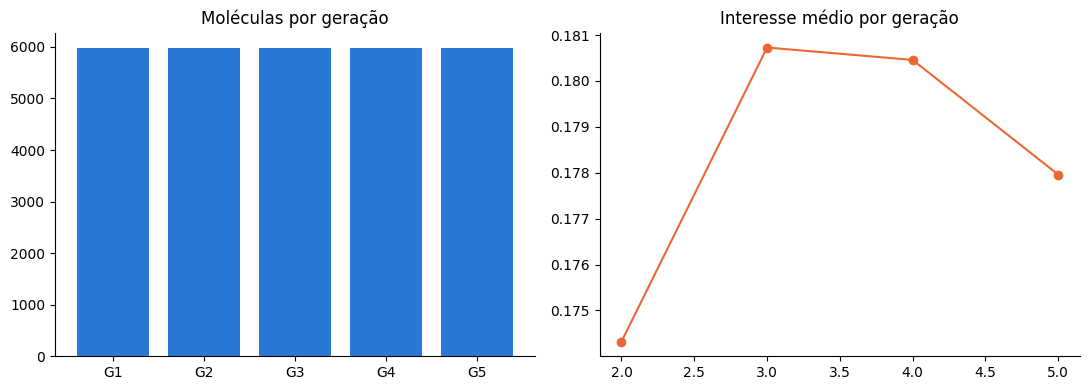

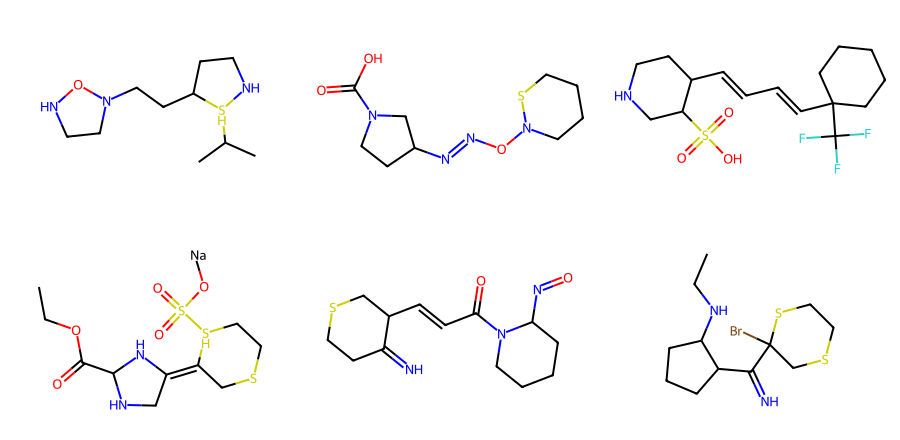

In [12]:
todas = pd.concat(historico.values(), ignore_index=True)
todas["reabre_no_rdkit"] = todas["smiles"].map(lambda s: Chem.MolFromSmiles(s) is not None)
print(f"Total: {len(todas):,} | únicas: {todas['smiles'].nunique():,}")
print(f"kekule_ok: {todas['kekule_ok'].mean():.1%} | aromatizada: {todas['aromatizada'].mean():.1%} "
      f"| reabre no RDKit: {todas['reabre_no_rdkit'].mean():.1%}")
print("Resolvido por nível de fallback:")
print(todas["nivel_fallback"].value_counts().sort_index().to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar([f"G{g}" for g in historico], [len(d) for d in historico.values()], color="#2a78d6")
ax[0].set_title("Moléculas por geração")
ax[1].plot(df_metricas["geracao"], df_metricas["interesse_medio"], marker="o", color="#eb6834")
ax[1].set_title("Interesse médio por geração")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in todas.loc[todas["reabre_no_rdkit"], "smiles"].sample(6, random_state=1)],
                     molsPerRow=3, subImgSize=(300, 220))

## Exportar

In [13]:
saida = RAIZ / "data"; saida.mkdir(exist_ok=True)
todas.drop(columns=["reabre_no_rdkit"]).to_csv(saida / "geracoes_v2.csv", index=False)
memoria.tabela().to_csv(saida / "aprendizado_v2.csv", index=False)
print("Exportado em", saida)

Exportado em C:\Users\Cliente\Documents\Git\gerador_smiles\data
